# Solutions to exercises on Python, data handling and cheminformatics

This notebook contains the suggested solutions for all exercises in the notebook.

Try to complete the exercises on your own before reviewing the answers. The goal is not only to obtain the correct output, but to understand the underlying concepts.

## Exercise 1 - Python & Pandas basics

Task: Create a dataset of reactions and analyze yields

In [1]:
import pandas as pd

# TODO: create lists
reaction_id = ["R1","R2","R3","R4","R5","R6","R7","R8"]
temperature = [25, 40, 55, 60, 35, 70, 80, 50]
yield_percent = [45, 60, 72, 68, 55, 80, 85, 65]

# TODO: create DataFrame
df = pd.DataFrame({
    "reaction_id": reaction_id,
    "temperature": temperature,
    "yield_percent": yield_percent
})

display(df)

# TODO: calculate average yield
average_yield = df["yield_percent"].mean()
print(f"Average Yield: {average_yield:.2f}%")

# TODO: find highest yield reaction
highest_yield_reaction = df.loc[df["yield_percent"].idxmax()]
print(f"Highest Yield Reaction: {highest_yield_reaction['reaction_id']} with {highest_yield_reaction['yield_percent']}%")

# TODO: create high_yield column (>70%)
df["high_yield"] = df["yield_percent"] > 70
display(df)

,reaction_id,temperature,yield_percent
0,R1,25,45
1,R2,40,60
2,R3,55,72
3,R4,60,68
4,R5,35,55
5,R6,70,80
6,R7,80,85
7,R8,50,65


Average Yield: 66.25%
Highest Yield Reaction: R7 with 85%


,reaction_id,temperature,yield_percent,high_yield
0,R1,25,45,False
1,R2,40,60,False
2,R3,55,72,True
3,R4,60,68,False
4,R5,35,55,False
5,R6,70,80,True
6,R7,80,85,True
7,R8,50,65,False


## Exercise 2 - Filtering & grouping

Task: Analyze the effect on temperature on yields

In [2]:
# TODO: filter reactions with temperature > 50
high_temp_reactions = df[df["temperature"] > 50]
display(high_temp_reactions)

# TODO: create bins
bins = [0, 40, 60, 100]
labels = ["low", "medium", "high"]

# TODO: assign bins
df["temperature_bin"] = pd.cut(df["temperature"], bins=bins, labels=labels)
display(df)

# TODO: group and average yield
average_yield_by_bin = df.groupby("temperature_bin")["yield_percent"].mean()
print(average_yield_by_bin)

,reaction_id,temperature,yield_percent,high_yield
2,R3,55,72,True
3,R4,60,68,False
5,R6,70,80,True
6,R7,80,85,True


,reaction_id,temperature,yield_percent,high_yield,temperature_bin
0,R1,25,45,False,low
1,R2,40,60,False,low
2,R3,55,72,True,medium
3,R4,60,68,False,medium
4,R5,35,55,False,low
5,R6,70,80,True,high
6,R7,80,85,True,high
7,R8,50,65,False,medium


temperature_bin
low       53.333333
medium    68.333333
high      82.500000
Name: yield_percent, dtype: float64


## Exercise 3 - Data visualization

Task: Plot the temperature vs yield

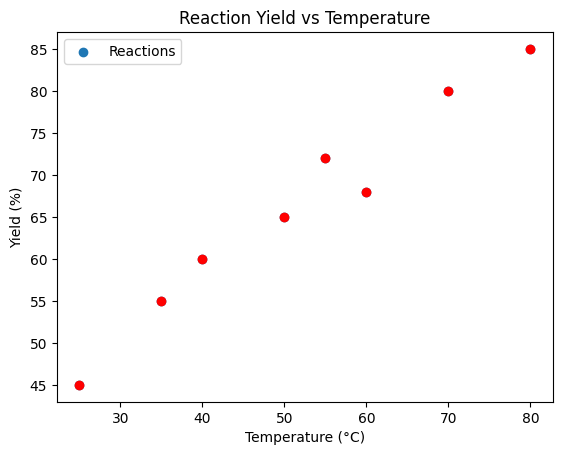

In [3]:
import matplotlib.pyplot as plt

# TODO: scatter plot
fig, ax = plt.subplots()
ax.scatter(df["temperature"], df["yield_percent"])

# TODO: label axes and title
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Yield (%)")
ax.set_title("Reaction Yield vs Temperature")

# TODO: add legend
ax.legend(["Reactions"])

# TODO: change line color
ax.scatter(df["temperature"], df["yield_percent"], color="red")
plt.show()

## Exercise 4 - RDKit and cheminformatics basics

Task: Convert SMILEs into molecules

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw

smiles_list = ["CCO", "c1ccccc1", "CC(=O)O"]

# TODO: convert to molecules
molecules = [Chem.MolFromSmiles(smiles) for smiles in smiles_list]

# TODO: display molecules
Draw.MolsToImage(molecules)

# TODO: create DataFrame
df_molecules = pd.DataFrame({
    "smiles": smiles_list,
    "molecule": molecules
})

display(df_molecules)

,smiles,molecule
0,CCO,<rdkit.Chem.rdchem.Mol object at 0x1124f11c0>
1,c1ccccc1,<rdkit.Chem.rdchem.Mol object at 0x1124f13f0>
2,CC(=O)O,<rdkit.Chem.rdchem.Mol object at 0x1124f1230>


## Exercise 5 - PubChem to RDKit pipeline

Task: Retrieve a molecule SMILES from [PubChem](https://pubchem.ncbi.nlm.nih.gov/) and visualize it

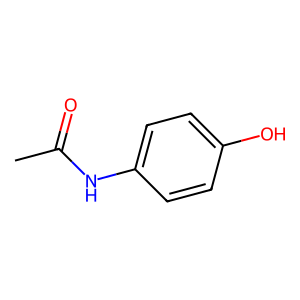

In [5]:
from rdkit import Chem
from rdkit.Chem import Draw

compound_smiles = "CC(Nc1ccc(O)cc1)=O"  # using paracetamol as an example

# TODO: convert to RDKit molecule
compound_molecule = Chem.MolFromSmiles(compound_smiles)

# TODO: display molecule
Draw.MolToImage(compound_molecule)

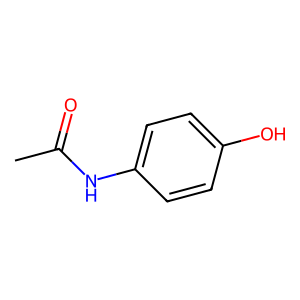

In [6]:
# As an alternative, you could use the PubChem python tool (PubChemPy) to fetch the compound information directly from PubChem using the compound name. Here's how you can do that:
# Link to PubChemPy: https://docs.pubchempy.org/en/latest/

import pubchempy as pcp

compound_name = "paracetamol"

compound = pcp.get_compounds(compound_name, 'name')[0]
compound_smiles = compound.smiles

molecule = Chem.MolFromSmiles(compound_smiles)
Draw.MolToImage(molecule)


## Bonus Exercise

Combining everything from above:

1. Create a dataset with a compound name and yield (you can make up the data and the molecules for this)
2. Get the SMILES of the molecules from PubChem
3. Calculate the molecular weight
4. Plot yield vs molecular weight

,compound,yield_percent,smiles,molecule,molecular_weight
0,aspirin,72,CC(=O)OC1=CC=CC=C1C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x1131cd4d0>,180.159
1,caffeine,85,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,<rdkit.Chem.rdchem.Mol object at 0x1131cd460>,194.194
2,ibuprofen,60,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x1131cd540>,206.285
3,glucose,91,C([C@@H]1[C@H]([C@@H]([C@H](C(O1)O)O)O)O)O,<rdkit.Chem.rdchem.Mol object at 0x1131cd380>,180.156
4,ethanol,45,CCO,<rdkit.Chem.rdchem.Mol object at 0x1131cd770>,46.069


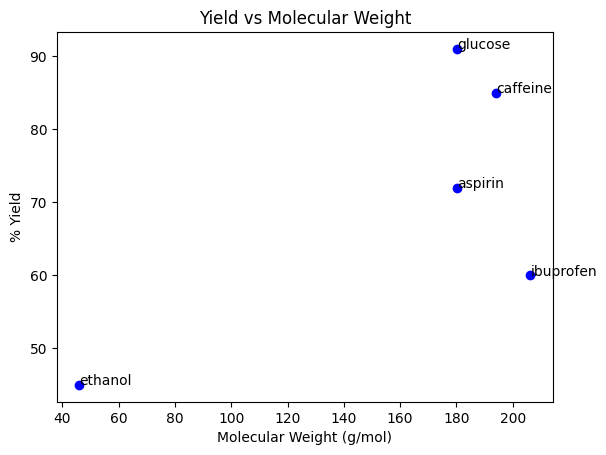

In [ ]:
from rdkit.Chem import Descriptors

compounds = ["aspirin", "caffeine", "ibuprofen", "glucose", "ethanol"]
yields = [72, 85, 60, 91, 45]

# TODO: build DataFrame
smiles = [pcp.get_compounds(name, 'name')[0].smiles for name in compounds]

df_bonus = pd.DataFrame({
    "compound": compounds,
    "yield_percent": yields,
    "smiles": smiles
})

# TODO: compute molecular weight
df_bonus["molecule"] = df_bonus["smiles"].apply(Chem.MolFromSmiles)
df_bonus["molecular_weight"] = df_bonus["molecule"].apply(Descriptors.MolWt)
display(df_bonus)

# TODO: plot
fig, ax = plt.subplots()
ax.scatter(df_bonus["molecular_weight"], df_bonus["yield_percent"], color="blue")

for _, row in df_bonus.iterrows():
    ax.annotate(row["compound"], (row["molecular_weight"], row["yield_percent"]))

ax.set_xlabel("Molecular Weight (g/mol)")
ax.set_ylabel("% Yield")
ax.set_title("Yield vs Molecular Weight")

plt.show()